<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
</div>


# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 4: Autocodificadores
### **Sesión 3/3: Autocodificadores variacionales**

**Autores**: Juan Morales Sánchez, Antonio Martínez Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya
___

### Objetivos

- Diseño de un *autoencoder* variacional.
- Comprender el aprendizaje probabilístico y las diferencias respecto a un *autoencoder* convencional
- Comprender el concepto de reparametrización y muestreo del espacio latente.
- Aplicación a la generación de imágenes.

### Contenidos
- [El dataset CelebA](#dataset)
- [*Autoencoder* variacional](#VAE)
- [Ejercicios](#ejercicios)

### Requisitos 
<a class='anchor' id='requisitos'></a>

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (*Machine Learning*)
- [Scikit-image](https://pypi.org/project/scikit-image/) (*Image Processing*)
- [Matplotlib](https://pypi.org/project/matplotlib/) y [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)
- [Tensorflow](https://www.tensorflow.org/) 2.x que incluye a [Keras](https://www.tensorflow.org/guide/keras) 2.x (*Deep Learning*)


<a class='anchor' id='dataset'></a>

## El dataset CelebA

En esta sesión de prácticas emplearemos también el dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64).

<a class='anchor' id='VAE'></a>

## *Autoencoder* variacional

Un *autoencoder* variacional (VAE) es un tipo específico de *autoencoder* generativo. Mientras que un autoencoder clásico se centra en aprender una representación compacta (o codificación) para reconstruir la entrada, un autoencoder generativo, como el VAE, va un paso más allá: aprende una distribución probabilística en el espacio latente que permite generar nuevas muestras.

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="imgs/VAE.png" style="height:300px; width:auto">
</div>

Podemos resumir las principales diferencias de un VAE respecto a un *autoencoder* convencional en:

- **Aprendizaje probabilístico:**  
  En un VAE se modela la codificación como una distribución, habitualmente gaussiana de media $\mu$ y varianza $\sigma$, lo que permite tomar muestras de dicha distribución en el espacio latente $z$ y generar datos nuevos. Esto contrasta con un *autoencoder* tradicional, que produce una representación determinista.

- **Pérdida combinada:**  
  Los VAE añaden a la función de pérdida no solo el error de reconstrucción, sino también un término de divergencia KL (Kullback-Leibler) que regulariza la distribución latente $z$ para que se aproxime a la distribución de probabilidad predeterminada. Esto facilita la generación de muestras coherentes y continuas en el espacio latente.

- **Generación de nuevos datos:**  
  Mediante al muestreo en el espacio latente los VAE pueden generar nuevas datos que son similares a los datos de entrenamiento, convirtiéndolos en modelos generativos efectivos.

  A continuación se muestra un ejemplo de resultados de generación de imágenes de caras mediante VAE a partir del dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64): 

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="imgs/generated_images.png" style="height:1000px; width:auto">
</div>

<a class='anchor' id='ejercicios'></a>

## Ejercicios

**E1:** Partiendo del trabajo de la sesión anterior, adapte un *autoencoder* convolucional de 3 niveles de profundidad, utilizando capas convolucionales 2D de 16, 32 y 64 mapas de características, más el nivel correspondiente al espacio latente (dimensión 64), para que se comporte como un *autoencoder* variacional. Para ello se debe atender a los aspectos puntualizados en el [apartado previo](#VAE) y [personalizar el modelo](https://www.tensorflow.org/guide/keras/making_new_layers_and_models_via_subclassing) para: 1) incorporar la reparametrización y muestro del espacio latente, forzando su estadística a una distribución normal (se requieren capas adicionales totalmente conectadas para enlazar con el nuevo espacio latente reparametrizado), y 2) implementación de la pérdida combinada (suma de la pérdida estándar del *autoencoder* con la pérdida de divergencia KL).

In [1]:
# Importar librerías necesarias
import os
import numpy as np
from tensorflow.keras.utils import get_file
from tensorflow.image import rgb_to_grayscale
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Descargar el dataset
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/therealcyberlord/50k-celeba-dataset-64x64"

dataset_path = get_file(origin=dataset_url, extract=True)

base_dir = os.path.join(
    os.path.dirname(dataset_path), "50k-celeba-dataset-64x64", "50k"
)
try:
    os.listdir(base_dir)
except Exception:
    base_dir = os.path.join(os.path.dirname(dataset_path), "50k")

print(f"Leyendo imágenes desde {base_dir:s}")

# Preparar listas para imágenes
NUMBER_OF_IMAGES = 20000  # <= 50000
IMAGE_DIM = (64, 64)

images = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 3))
images_gray = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 1))
for i, img_file in enumerate(os.listdir(base_dir)):
    if (i > 0) and (i % 1000 == 0):
        print(f"Cargadas {i:d} imágenes...")
    if i == NUMBER_OF_IMAGES:
        break
    img_path = os.path.join(base_dir, img_file)
    img = load_img(
        img_path, target_size=IMAGE_DIM, color_mode="rgb"
    )  # Redimensionar imágenes
    images[i] = img_to_array(img) / 255.0  # Normalizar a [0, 1]
    images_gray[i] = rgb_to_grayscale(images[i])

I0000 00:00:1778053179.541511   78239 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778053179.938412   78239 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778053181.801787   78239 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Leyendo imágenes desde /home/pyros05/.keras/datasets/50k-celeba-dataset-64x64/50k


W0000 00:00:1778053187.366375   78239 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778053187.376549   78239 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778053187.513148   78239 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1778053187.514152   78239 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5783 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Cargadas 1000 imágenes...
Cargadas 2000 imágenes...
Cargadas 3000 imágenes...
Cargadas 4000 imágenes...
Cargadas 5000 imágenes...
Cargadas 6000 imágenes...
Cargadas 7000 imágenes...
Cargadas 8000 imágenes...
Cargadas 9000 imágenes...
Cargadas 10000 imágenes...
Cargadas 11000 imágenes...
Cargadas 12000 imágenes...
Cargadas 13000 imágenes...
Cargadas 14000 imágenes...
Cargadas 15000 imágenes...
Cargadas 16000 imágenes...
Cargadas 17000 imágenes...
Cargadas 18000 imágenes...
Cargadas 19000 imágenes...
Cargadas 20000 imágenes...


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 1. Capa de muestreo (Reparametrization trick)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 64

# 2. Encoder Conv2D (16 -> 32 -> 64)
encoder_inputs = keras.Input(shape=(64, 64, 3))
x = layers.Conv2D(16, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 3. Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(16, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# 4. VAE Personalizado
class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=1.0, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # Pérdida de reconstrucción (binary crossentropy)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            # Divergencia KL
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            # Pérdida combinada (con ponderación KL)
            total_loss = reconstruction_loss + (self.kl_weight * kl_loss)
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

**E2:** Entrene el modelo con las imágenes de caras en color, y genere conjuntos de nuevas imágenes, similares a los mostrados en el [apartado previo](#VAE). Comente las diferencias en cuando a prestaciones con un *autoencoder* convolucional: calidad de la reconstrucción conseguida, número de parámetros necesarios en el modelo, tiempo de entrenamiento, etc. Tenga en cuenta que dado que el objetivo fundamental en este caso es generar imágenes y no reconstruirlas, los conjuntos de validación y test son prescindibles, y la parada anticipada puede realizarse directamente sobre el conjunto de entrenamiento (el sobreajuste puede mejorar la capacidad de generación de imágenes).

Epoch 1/30


I0000 00:00:1778053222.463252   78655 service.cc:153] XLA service 0x7d4ec4006f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778053222.463278   78655 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.18.1)
I0000 00:00:1778053222.566587   78655 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778053223.049670   78655 cuda_dnn.cc:461] Loaded cuDNN version 91801
I0000 00:00:1778053223.081204   78655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_264170__.17
I0000 00:00:1778053227.717734   79689 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778053229.043896   79689 subprocess_compilation.cc:348

  8/157 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - kl_loss: 0.0598 - loss: 2836.1350 - reconstruction_loss: 2836.0751

I0000 00:00:1778053238.112657   78655 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - kl_loss: 6.0792 - loss: 2715.9813 - reconstruction_loss: 2709.9021

I0000 00:00:1778053242.753200   78655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_264170__.17
I0000 00:00:1778053244.408574   80661 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_8', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778053248.857976   80665 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 4 bytes spill stores, 4 bytes spill loads



157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - kl_loss: 13.1067 - loss: 2616.6445 - reconstruction_loss: 2603.5374
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - kl_loss: 32.8467 - loss: 2370.0676 - reconstruction_loss: 2337.2227
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - kl_loss: 34.9980 - loss: 2330.9026 - reconstruction_loss: 2295.9048
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - kl_loss: 34.5693 - loss: 2310.3477 - reconstruction_loss: 2275.7786
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - kl_loss: 32.9734 - loss: 2300.4358 - reconstruction_loss: 2267.4622
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - kl_loss: 31.8554 - loss: 2292.8950 - reconstruction_loss: 2261.0405
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - kl_loss: 30.8323 - loss: 2287.0564 - reconstruction_loss: 2256.2239
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - kl_loss: 29.6724 - loss: 2282.6570 - reconstruction_loss: 2252.9854
Epoch 9/30
157/157 ━━━━━━━

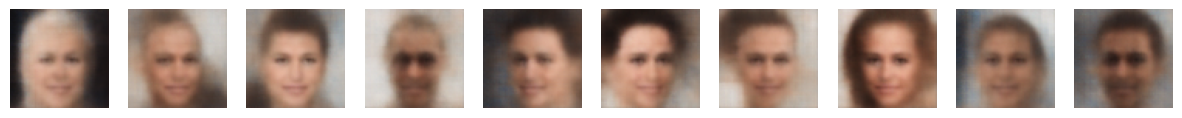

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

# Entrenamiento
early_stopping = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)

history = vae.fit(images, epochs=30, batch_size=128, callbacks=[early_stopping])

# Generación de imágenes nuevas aleatorias desde el espacio latente
def generar_imagenes(decoder, n=5):
    # Toma valores de la distribución normal N(0,1)
    z_sample = np.random.normal(size=(n, latent_dim))
    imagenes_generadas = decoder.predict(z_sample)

    fig, axes = plt.subplots(1, n, figsize=(15, 3)) 
    for i in range(n):
        axes[i].imshow(imagenes_generadas[i])
        axes[i].axis('off')
    plt.show()

generar_imagenes(vae.decoder, n=10)

**Análisis de diferencias respecto a un *autoencoder* convolucional:**

- **Calidad de la reconstrucción:** El VAE sacrifica precisión en la reconstrucción debido al término de regularización KL, que fuerza al espacio latente a aproximarse a una N(0, I). Las imágenes reconstruidas (y sobre todo las generadas) son más borrosas que las de un AE convolucional clásico, especialmente en los detalles finos (rasgos faciales, texturas, fondo).
- **Número de parámetros:** El VAE introduce dos cabezas densas adicionales en el encoder (`z_mean` y `z_log_var`) en lugar de una sola, por lo que tiene ligeramente más parámetros que un AE convolucional con la misma arquitectura base, aunque en términos relativos la diferencia es pequeña.
- **Tiempo de entrenamiento:** Cada época es comparable a la del AE convencional, pero la convergencia tiende a ser más lenta debido a la pérdida combinada (reconstrucción + KL) y a la estocasticidad introducida por el muestreo.
- **Capacidad generativa:** A diferencia del AE convolucional —cuyo espacio latente no tiene por qué ser continuo ni cubrir uniformemente todas las regiones— el VAE permite muestrear directamente de N(0, I) y obtener imágenes coherentes, lo que lo convierte en un verdadero modelo generativo.

**E3:** Evalúe la influencia sobre las prestaciones analizadas en el ejercicio E2 de:
- El aumento de la dimensión del espacio latente (máximo 1024).
- La ponderación de las pérdidas en la implementación de la suma de la pérdida combinada (desde 1 a 1, hasta un máximo de 10 a 1, orientativamente).

Para evaluar la influencia de cada hiperparámetro de forma aislada, se realizan dos experimentos independientes partiendo del modelo base de E2 (`latent_dim=64`, `kl_weight=1.0`):

- **Experimento A:** se aumenta únicamente la dimensión del espacio latente a 1024, manteniendo `kl_weight=1.0`.
- **Experimento B:** se aumenta únicamente la ponderación KL a 10, manteniendo `latent_dim=64`.

In [4]:
# Función auxiliar para construir un VAE con hiperparámetros configurables
def construir_vae(latent_dim_, kl_weight_):
    enc_in = keras.Input(shape=(64, 64, 3))
    x = layers.Conv2D(16, 3, activation="relu", strides=2, padding="same")(enc_in)
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    # La capa intermedia se escala con la dimensión latente para evitar un cuello de botella artificial
    x = layers.Dense(max(128, latent_dim_ * 2), activation="relu")(x)
    zm = layers.Dense(latent_dim_, name="z_mean")(x)
    zlv = layers.Dense(latent_dim_, name="z_log_var")(x)
    zz = Sampling()([zm, zlv])
    enc = keras.Model(enc_in, [zm, zlv, zz])

    dec_in = keras.Input(shape=(latent_dim_,))
    y = layers.Dense(8 * 8 * 64, activation="relu")(dec_in)
    y = layers.Reshape((8, 8, 64))(y)
    y = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(y)
    y = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(y)
    y = layers.Conv2DTranspose(16, 3, activation="relu", strides=2, padding="same")(y)
    dec_out = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(y)
    dec = keras.Model(dec_in, dec_out)

    m = VAE(enc, dec, kl_weight=kl_weight_)
    m.compile(optimizer=keras.optimizers.Adam())
    return m

def generar_imagenes_dinamico(decoder_model, dim_latente, n=5):
    z_sample = np.random.normal(size=(n, dim_latente))
    imagenes_generadas = decoder_model.predict(z_sample, verbose=0)
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        axes[i].imshow(imagenes_generadas[i])
        axes[i].axis('off')
    plt.show()

early_stopping = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)

**Experimento A — Aumento de la dimensión latente (64 → 1024):**

Epoch 1/30


I0000 00:00:1778053339.376368   78654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_294140__.17
I0000 00:00:1778053342.883009   84827 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778053344.208100   84827 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 40 bytes spill stores, 32 bytes spill loads

I0000 00:00:1778053344.379807   84828 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 16 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778053344.465263   84830 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 16 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778053344.562114   84838 subprocess_compilation.cc:348] ptxas warn

153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - kl_loss: 11.1461 - loss: 2685.5787 - reconstruction_loss: 2674.4328

I0000 00:00:1778053349.353287   78654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_294140__.17
I0000 00:00:1778053350.370943   85437 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_30', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778053351.658582   85437 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 48 bytes spill stores, 44 bytes spill loads

I0000 00:00:1778053353.416702   85439 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1778053353.532147   85437 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 8 bytes spill stores, 8 bytes spill loads



157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - kl_loss: 20.7453 - loss: 2565.7229 - reconstruction_loss: 2544.9783
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - kl_loss: 36.3943 - loss: 2379.7646 - reconstruction_loss: 2343.3701
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - kl_loss: 39.5766 - loss: 2354.4199 - reconstruction_loss: 2314.8423
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - kl_loss: 42.2977 - loss: 2340.1150 - reconstruction_loss: 2297.8154
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - kl_loss: 44.0816 - loss: 2330.2366 - reconstruction_loss: 2286.1548
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - kl_loss: 45.3994 - loss: 2323.7622 - reconstruction_loss: 2278.3640
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - kl_loss: 47.0391 - loss: 2316.7151 - reconstruction_loss: 2269.6758
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - kl_loss: 48.4249 - loss: 2312.1243 - reconstruction_loss: 2263.6982
Epoch 9/30
157/157 ━━━━━━━

I0000 00:00:1778053414.739106   88815 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778053414.865439   88813 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 4 bytes spill stores, 4 bytes spill loads



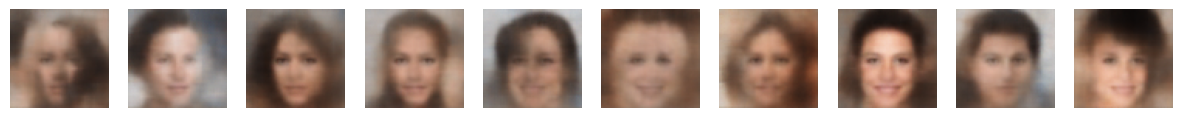

In [5]:
latent_dim_A = 1024
vae_A = construir_vae(latent_dim_=latent_dim_A, kl_weight_=1.0)
history_A = vae_A.fit(images, epochs=30, batch_size=128, callbacks=[early_stopping])
generar_imagenes_dinamico(vae_A.decoder, latent_dim_A, n=10)

**Experimento B — Aumento del peso de la pérdida KL (1 → 10):**

Epoch 1/30


I0000 00:00:1778053417.850948   78654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_324130__.17


152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - kl_loss: 0.6404 - loss: 2746.2884 - reconstruction_loss: 2739.8850

I0000 00:00:1778053421.655822   78657 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_324130__.17


157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - kl_loss: 1.4007 - loss: 2680.0386 - reconstruction_loss: 2666.0322
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - kl_loss: 2.3934 - loss: 2583.7893 - reconstruction_loss: 2559.8552
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - kl_loss: 2.5045 - loss: 2573.1377 - reconstruction_loss: 2548.0925
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 2.5332 - loss: 2570.9124 - reconstruction_loss: 2545.5813
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 2.5150 - loss: 2567.8855 - reconstruction_loss: 2542.7356


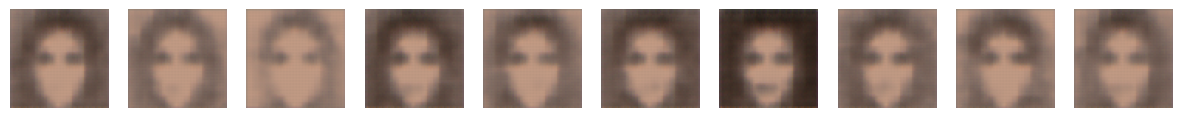

In [6]:
latent_dim_B = 64
vae_B = construir_vae(latent_dim_=latent_dim_B, kl_weight_=10.0)
history_B = vae_B.fit(images, epochs=30, batch_size=128, callbacks=[early_stopping])
generar_imagenes_dinamico(vae_B.decoder, latent_dim_B, n=10)

**Análisis E3:**

- **Aumento de la dimensión latente (Experimento A):** Con `latent_dim=1024` el modelo dispone de mucha más capacidad de codificación, lo que reduce el error de reconstrucción sobre el conjunto de entrenamiento. Sin embargo, dado que la pérdida KL se distribuye entre 1024 dimensiones, su efecto regularizador por dimensión se diluye y el espacio latente tiende a ser menos compacto. En la generación a partir de N(0, I) suelen aparecer muestras menos coherentes (más artefactos), porque parte de las dimensiones latentes apenas se usan ("posterior collapse" parcial). Además, el número de parámetros y el tiempo de entrenamiento crecen notablemente.
- **Aumento del peso de la pérdida KL (Experimento B):** Al ponderar la KL con un factor 10, la regularización es mucho más estricta y el espacio latente se ajusta con mayor fidelidad a N(0, I). Esto mejora la calidad y diversidad de las imágenes muestreadas (transiciones más suaves) a costa de una mayor borrosidad: el término de reconstrucción tiene menos peso relativo, por lo que el modelo "promedia" más las salidas. En el extremo, pesos KL muy altos pueden provocar que el decoder ignore el código latente y siempre produzca una imagen promedio.

**E4:** Volviendo a la configuración del ejercicio E2. codifique todas las imágenes de entrenamiento en el espacio latente, y aplique a las codificaciones resultantes una reducción de dimensionalidad a 2 dimensiones con el [algoritmo PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), y compruebe mediante representación visual de dichas componentes si la estadística de dicho espacio se ajusta la predeterminada.

I0000 00:00:1778053431.030497   78655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_328635__.1
I0000 00:00:1778053432.318484   78655 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion', 8 bytes spill stores, 8 bytes spill loads



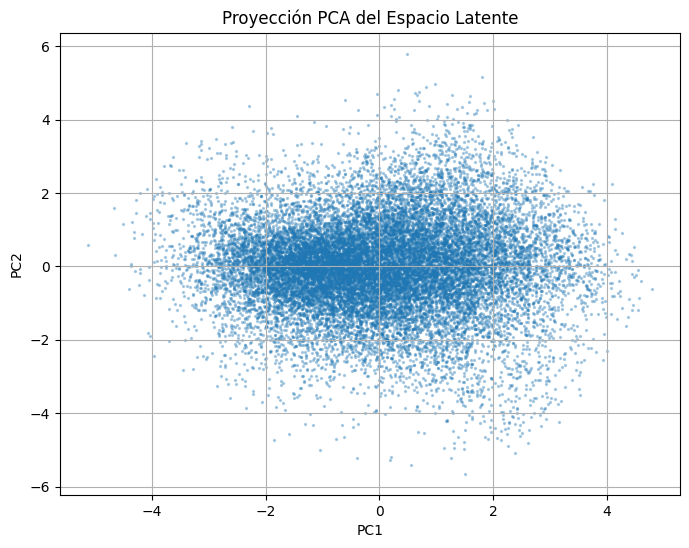

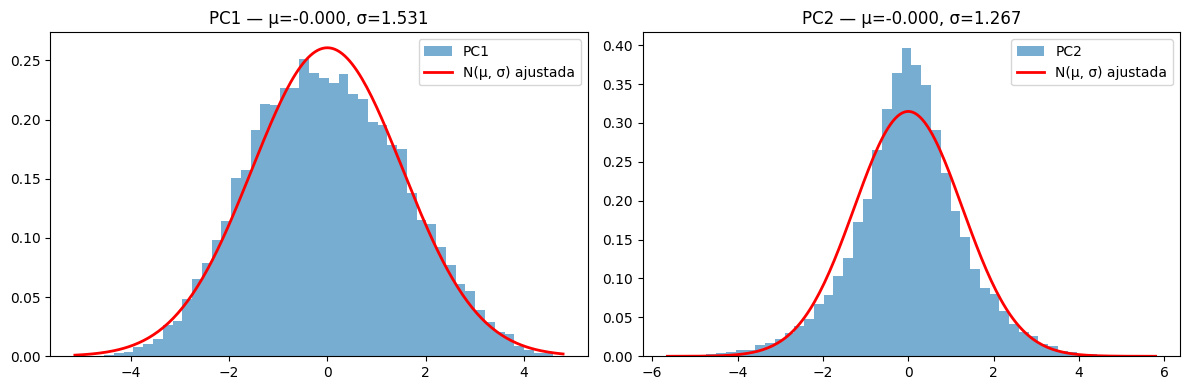

Media global de z_mean : 0.0087  (esperado ≈ 0)
Desv. global de z_mean : 0.4587  (esperado ≈ 1)
PC1: estadístico=245.44, p-valor=5.043e-54
PC2: estadístico=414.54, p-valor=9.612e-91


In [7]:
from sklearn.decomposition import PCA
from scipy import stats

# Extraemos solo las codificaciones medias (z_mean)
z_mean_train, _, _ = vae.encoder.predict(images, verbose=0)

pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_mean_train)

# Scatter de las dos primeras componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(z_pca[:, 0], z_pca[:, 1], alpha=0.3, s=2)
plt.title("Proyección PCA del Espacio Latente")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# Comprobación visual de gaussianidad: histogramas de PC1 y PC2 con la PDF normal ajustada
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, ax in enumerate(axes):
    datos = z_pca[:, i]
    ax.hist(datos, bins=50, density=True, alpha=0.6, label=f"PC{i+1}")
    xs = np.linspace(datos.min(), datos.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, loc=datos.mean(), scale=datos.std()),
            'r-', lw=2, label="N(μ, σ) ajustada")
    ax.set_title(f"PC{i+1} — μ={datos.mean():.3f}, σ={datos.std():.3f}")
    ax.legend()
plt.tight_layout()
plt.show()

# Estadísticas globales del espacio latente original (esperado: μ ≈ 0, σ ≈ 1 por dimensión)
print(f"Media global de z_mean : {z_mean_train.mean():.4f}  (esperado ≈ 0)")
print(f"Desv. global de z_mean : {z_mean_train.std():.4f}  (esperado ≈ 1)")

# Test de normalidad de D'Agostino-Pearson sobre cada componente principal
for i in range(2):
    stat, p = stats.normaltest(z_pca[:, i])
    print(f"PC{i+1}: estadístico={stat:.2f}, p-valor={p:.4g}")

**Análisis E4:** Si la regularización KL está cumpliendo su función, los histogramas de PC1 y PC2 deberían aproximarse a una distribución normal centrada y la media/desviación globales de `z_mean` deberían quedar próximas a 0 y 1 respectivamente. En la práctica, debido a la tensión con la pérdida de reconstrucción, la distribución suele ser cercana a la normal pero no exactamente gaussiana (p-valores pequeños en el test, ligeras colas pesadas o asimetrías). El scatter PCA debería formar una nube aproximadamente circular sin huecos significativos, lo que es coherente con el hecho de que el muestreo de N(0, I) genera imágenes plausibles.

**E5:** Dadas las particularidades del conjunto de datos (imágenes de caras), resulta directo aplicar un aumento de datos trivial que duplique el tamaño del conjunto de entrenamiento, y que consiste en realizar un giro especular (horizontal) a cada una de las imágenes, y añadir dichas imágenes al conjunto inicial de entrenamiento. Implemente dicho aumento de datos y comente su influencia en la calidad de las imágenes generadas. En función de las posibilidades de cómputo, aumente también la cantidad de imágenes del conjunto de entrenamiento que se leen inicialmente del dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64)

El conjunto inicial ya se ha ampliado en el ejercicio E1 (`NUMBER_OF_IMAGES = 20000`). Aquí aplicamos además el aumento de datos por giro especular horizontal, que duplica el conjunto de entrenamiento sin coste adicional de lectura.

Número total de imágenes tras Data Augmentation: 40000
Epoch 1/30


I0000 00:00:1778053439.505305   78654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_344711__.17


312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - kl_loss: 13.3274 - loss: 2622.8367 - reconstruction_loss: 2609.5098

I0000 00:00:1778053444.732851   78656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_344711__.17
I0000 00:00:1778053445.775206   90185 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_8', 8 bytes spill stores, 8 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - kl_loss: 24.1760 - loss: 2476.1621 - reconstruction_loss: 2451.9880
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 36.6191 - loss: 2306.3745 - reconstruction_loss: 2269.7559
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 37.0088 - loss: 2278.7954 - reconstruction_loss: 2241.7866
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 36.6445 - loss: 2264.8030 - reconstruction_loss: 2228.1584
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 35.9274 - loss: 2256.1143 - reconstruction_loss: 2220.1855
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 35.0551 - loss: 2250.3384 - reconstruction_loss: 2215.2844
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 34.2193 - loss: 2246.8201 - reconstruction_loss: 2212.6013
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 33.5202 - loss: 2244.1506 - reconstruction_loss: 2210.6311
Epoch 9/30
313/313 ━━━━━━━

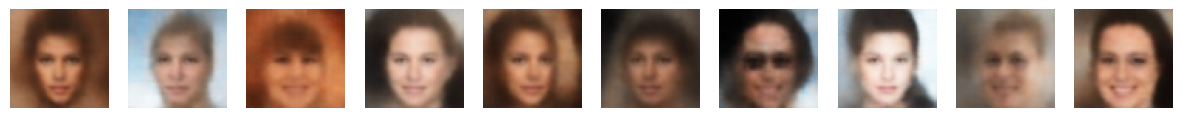

In [8]:
# Aumento de datos: giro especular horizontal
# axis=2 es el eje horizontal (N, H, W, C) -> voltear columnas
X_train_flipped = np.flip(images, axis=2)
X_train_augmented = np.concatenate((images, X_train_flipped), axis=0).astype(np.float32)

print(f"Número total de imágenes tras Data Augmentation: {X_train_augmented.shape[0]}")

# Para evitar problemas de memoria al pasar tensores muy grandes,
# creamos un tf.data.Dataset para gestionar la carga en lotes.
train_dataset = (
    tf.data.Dataset.from_tensor_slices(X_train_augmented)
    .shuffle(buffer_size=2048)
    .batch(128)
    .prefetch(tf.data.AUTOTUNE)
)

# Reinstanciamos un VAE limpio para que el entrenamiento parta de cero y
# la comparación con E2 sea justa (mismo número de épocas, distinto dataset).
vae_aug = construir_vae(latent_dim_=64, kl_weight_=1.0)
early_stopping = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)
history_aug = vae_aug.fit(train_dataset, epochs=30, callbacks=[early_stopping])

# Generación de nuevas imágenes tras el aumento de datos
generar_imagenes_dinamico(vae_aug.decoder, 64, n=10)

**Análisis E5:** El giro especular horizontal es un aumento de datos coherente con la naturaleza del *dataset* (las caras son aproximadamente simétricas), por lo que duplicar el conjunto sin introducir distribuciones espurias es prácticamente "gratis". Sus efectos esperables son:

- **Mayor diversidad efectiva del conjunto de entrenamiento**, lo que ayuda al VAE a cubrir mejor el espacio latente y reduce el sobreajuste a poses concretas.
- **Imágenes generadas de mayor calidad y variedad**, especialmente en cuanto a orientación de la cara y disposición de rasgos asimétricos (peinado, dirección de la mirada).
- **Tiempo de entrenamiento por época aproximadamente el doble**, al haber el doble de muestras, pero la convergencia suele ser más estable.
- **Combinado con el aumento del número de imágenes leídas inicialmente** (de 10000 a 20000 en E1, lo que da 40000 tras el flip), se observa una mejora cualitativa en la nitidez y coherencia de las caras generadas respecto a E2.
